# Modelagem e Comparação de Modelos

## 1. Importando bibliotecas

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import json

from src import data_prep, modeling, evaluation, interpretability, visualization

visualization.set_style()
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

RANDOM_STATE = 42
PROCESSED_DIR = ROOT / "data" / "processed"
MODELS_DIR = ROOT / "models"

## 2. Separação dos dados e definição do modelo baseline

In [2]:
X_train, X_test, y_train, y_test = data_prep.load_processed_split()

target = data_prep.TARGET
features = list(X_train.columns)


with open(PROCESSED_DIR / "baseline.json", "r") as f:
    baseline_result = json.load(f)

baseline_value = baseline_result["constant"]
baseline_metrics = baseline_result["metrics"]

print(f"Baseline (média do treino = R$ {baseline_value:.1f})")

for k, v in baseline_metrics.items():
    print(f"  {k} = {v:.3f}")

Baseline (média do treino = R$ 2388.3)
  MAE = 418.924
  RMSE = 520.454
  R2 = -0.002
  MAPE = 0.198


## 3. Comparar os modelos

In [3]:
models = modeling.get_models()
results_df, preds_test = evaluation.evaluate_models(models, X_train, y_train, X_test, y_test)
results_df

,modelo,MAE,RMSE,R2,MAPE
0,GradientBoosting,283.708130,352.559216,0.540296,0.130046
1,Ridge,288.399634,357.656691,0.526907,0.130949
2,Linear,288.415606,357.686779,0.526827,0.130951
3,RandomForest,287.368908,362.780748,0.513254,0.132757
4,XGBoost,317.876756,394.697322,0.423841,0.143301
5,DecisionTree,352.062169,440.616263,0.281982,0.162488


## 4. Avaliar MAE, RMSE, R² e MAPE

In [4]:
comparison = pd.concat([
    pd.DataFrame([{"modelo": "Baseline (média)", **baseline_metrics}]),
    results_df,
], ignore_index=True).sort_values("RMSE").reset_index(drop=True)
comparison["ganho_RMSE_vs_baseline"] = 1 - comparison["RMSE"] / baseline_metrics["RMSE"]
comparison.to_csv(PROCESSED_DIR / "model_comparison.csv", index=False)
comparison

,modelo,MAE,RMSE,R2,MAPE,ganho_RMSE_vs_baseline
0,GradientBoosting,283.708130,352.559216,0.540296,0.130046,0.322594
1,Ridge,288.399634,357.656691,0.526907,0.130949,0.312799
2,Linear,288.415606,357.686779,0.526827,0.130951,0.312741
3,RandomForest,287.368908,362.780748,0.513254,0.132757,0.302954
4,XGBoost,317.876756,394.697322,0.423841,0.143301,0.241630
5,DecisionTree,352.062169,440.616263,0.281982,0.162488,0.153401
6,Baseline (média),418.923653,520.454484,-0.001797,0.198052,0.000000


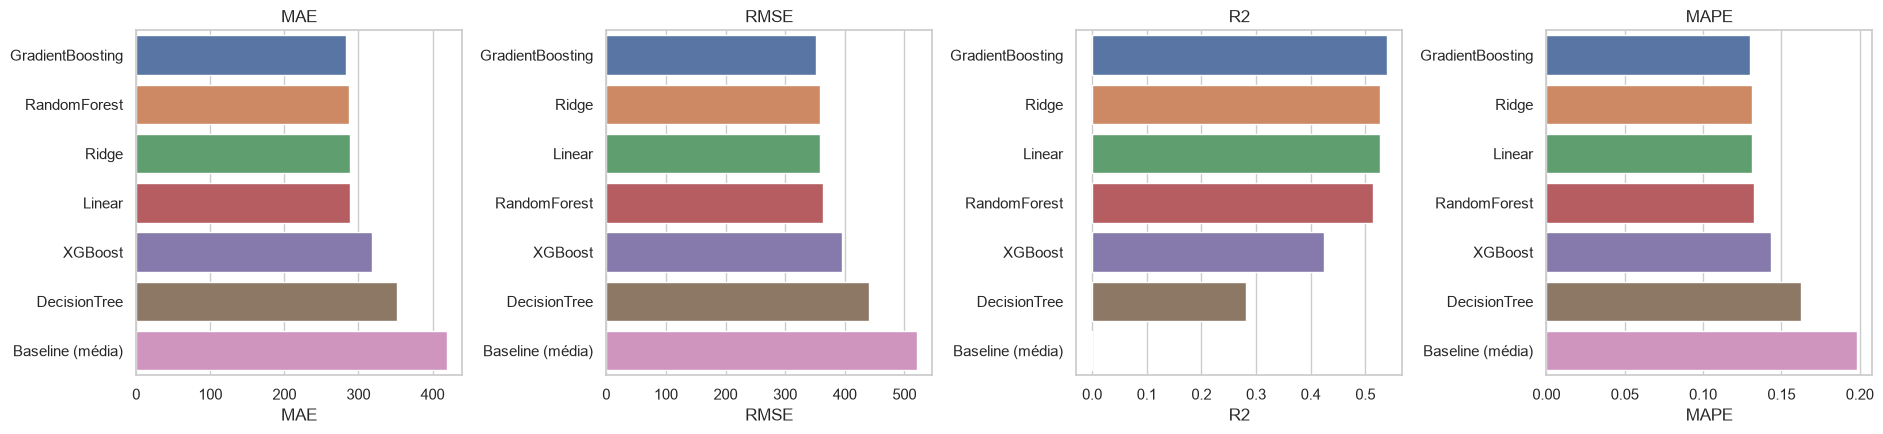

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4.5))
for ax, metric in zip(axes, ["MAE", "RMSE", "R2", "MAPE"]):
    order = comparison.sort_values(metric, ascending=(metric != "R2"))
    sns.barplot(data=order, x=metric, y="modelo", ax=ax, palette="deep")
    ax.set_title(metric)
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

* Todos os modelos superaram o baseline, mostrando bom desempenho.
* Gradient Boosting,  Ridge e Linear tiveram os melhores resultados.
* Como os resultados são próximos, a escolha final não deve depender apenas de uma única avaliação no teste.

## 5. Previsto X Observado

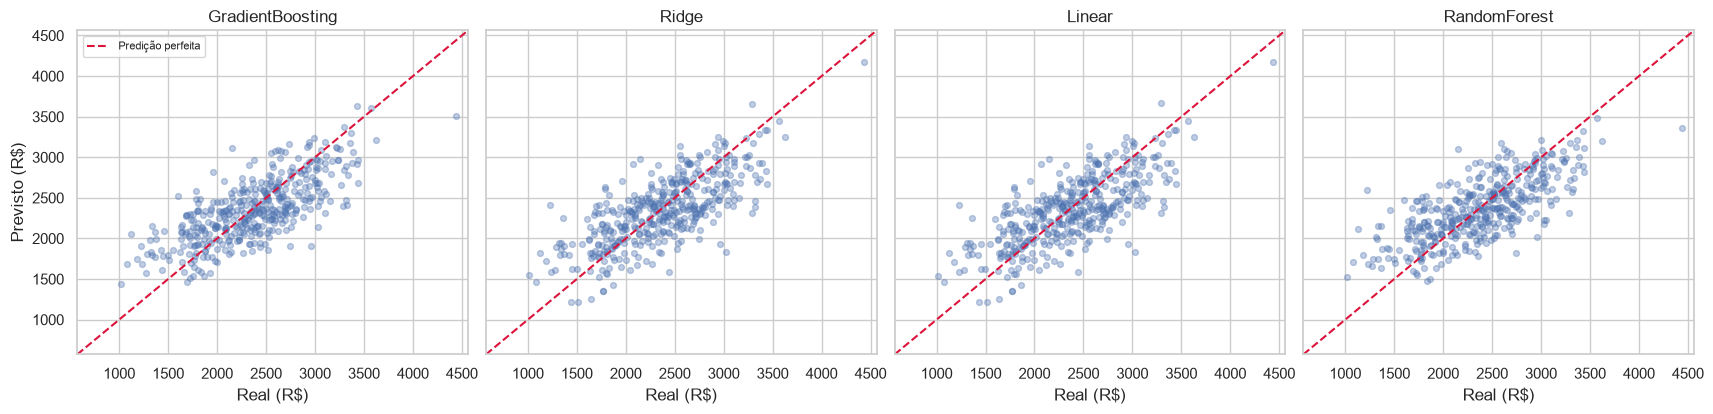

In [6]:
top_models = comparison[comparison["modelo"] != "Baseline (média)"].sort_values("RMSE").head(4)["modelo"].tolist()

fig, axes = plt.subplots(1, len(top_models), figsize=(4.3 * len(top_models), 4.3), sharex=True, sharey=True)
lims = [y_train.min() * 0.95, y_train.max() * 1.05]
for ax, name in zip(axes, top_models):
    visualization.plot_pred_vs_actual(ax, y_test, preds_test[name], name, lims)
    ax.set_xlabel("Real (R$)")
axes[0].set_ylabel("Previsto (R$)")
axes[0].legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

* Os pontos ficam bem próximos da linha no meio do intervalo de gasto.
* Para gasto baixo, os modelos tendem a prever a mais. Para gasto alto, tendem a prever a menos.
* Um cliente aparece como outlier nos quatro modelos, com erro bem maior que o normal.
* Ridge e Linear têm padrões quase iguais entre si.
* GradientBoosting e RandomForest erram mais nas pontas do intervalo, principalmente em valores baixos.